In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# 1. Load Data

In [ ]:
data_dir = "C:/Users/Admin/Desktop/22-Machine_Learning-Projects/data"
df = pd.read_csv(f'{data_dir}/3_BuildLinearRegression(no scikit-learn, just math)/Salary_Data.csv')
print(df.shape)
df.head()

(30, 2)


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [ ]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

# 2. Train Test

In [ ]:
training_set = df.sample(frac=0.8, random_state=42)
testing_set = df.drop(training_set.index)

In [ ]:
X_train = df["YearsExperience"].values
y_train = df["Salary"].values

In [ ]:
y_train

array([ 39343.,  46205.,  37731.,  43525.,  39891.,  56642.,  60150.,
        54445.,  64445.,  57189.,  63218.,  55794.,  56957.,  57081.,
        61111.,  67938.,  66029.,  83088.,  81363.,  93940.,  91738.,
        98273., 101302., 113812., 109431., 105582., 116969., 112635.,
       122391., 121872.])

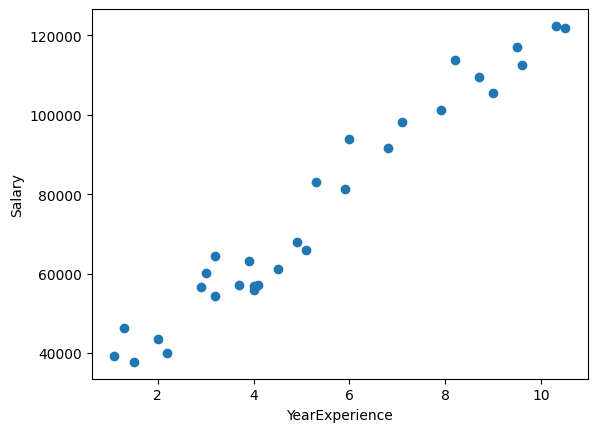

In [ ]:
plt.scatter(X_train, y_train)
plt.xlabel("YearExperience")
plt.ylabel("Salary")
plt.show()

In [ ]:
def cost_function(x, y , w, b):
    m = len(x)
    cost_sum = 0
    
    for i in range(m):
        f = w * x[i] + b
        cost = (f - y[i]) ** 2
        cost_sum += cost
        
    total_cost = (1 / (2 * m)) * cost_sum
    
    return total_cost

In [ ]:
def gradient_function(x, y, w, b):
    m = len(x)
    dc_dw = 0
    dc_db = 0
    
    for i in range(m):
        f = w * x[i] + b
        
        dc_dw += (f - y[i]) * x[i]
        dc_db += (f - y[i])
    
    dc_dw = (1 / m) * dc_dw
    dc_db = (1 / m) * dc_db
    
    print(dc_dw, dc_db)
    
    return dc_dw, dc_db

In [ ]:
def gradient_descent (x, y, alpha , interations):
    w = 0
    b = 0
    
    for i in range (interations):
        dc_dw, dc_db = gradient_function(x ,y, w, b)
        
        w = w - alpha * dc_dw
        b = b - alpha * dc_db
        
        print(f"Iteration {i}: Cost {cost_function(x , y, w, b)}")
    
    return w, b

In [ ]:
learning_rate = 0.01
iterations = 10000

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, iterations)
print(f"w: {final_w: .4f}, b: {final_b: .4f}")

-477398.7 -76003.0
Iteration 0: Cost 1344612525.8413548
-301417.30881666666 -49877.18573999999
Iteration 1: Cost 582933639.1249903
-190206.7002888785 -33363.107540807774
Iteration 2: Cost 278595825.9816312
-119927.89395416583 -22923.160456717287
Iteration 3: Cost 156901936.81054005
-75515.88022274022 -16321.760086718767
Iteration 4: Cost 108149191.53202362
-47450.347843242285 -12146.132050016644
Iteration 5: Cost 88526795.5063979
-29714.94974544362 -9503.47558077887
Iteration 6: Cost 80538511.12387824
-18507.664009600936 -7829.586495163173
Iteration 7: Cost 77197055.8093798
-11425.808326366654 -6767.916749168081
Iteration 8: Cost 75711992.7100282
-6951.011050881134 -6093.146299268781
Iteration 9: Cost 74968933.0700283
-4123.739397354344 -5662.88444910595
Iteration 10: Cost 74522833.02695376
-2337.617997344758 -5387.147584635471
Iteration 11: Cost 74195957.63300419
-1209.448806970771 -5209.0706725301925
Iteration 12: Cost 73917324.17093241
-497.07037325968946 -5092.717919194512
Iteratio

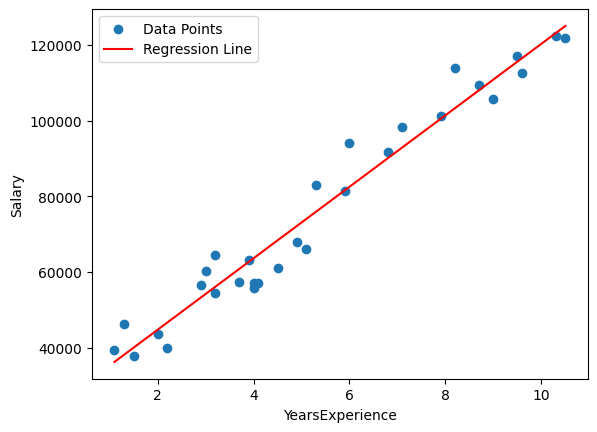

In [ ]:
plt.scatter(X_train, y_train , label = "Data Points")

x_vals = np.linspace(min(X_train), max(X_train), 100)
y_vals = final_w * x_vals + final_b
plt.plot(x_vals, y_vals, color='red', label = 'Regression Line')

plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.legend()
plt.show()
